<a href="https://www.kaggle.com/code/nusybamohamadd/cancer-notebook?scriptVersionId=315098389" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/hattoriyoung
/kaggle/input/datasets/hattoriyoung/skin-cancer-data
/kaggle/input/datasets/hattoriyoung/skin-cancer-data/data
/kaggle/input/datasets/hattoriyoung/skin-cancer-data/data/test
/kaggle/input/datasets/hattoriyoung/skin-cancer-data/data/test/benign
/kaggle/input/datasets/hattoriyoung/skin-cancer-data/data/test/malignant
/kaggle/input/datasets/hattoriyoung/skin-cancer-data/data/train
/kaggle/input/datasets/hattoriyoung/skin-cancer-data/data/train/benign
/kaggle/input/datasets/hattoriyoung/skin-cancer-data/data/train/malignant
/kaggle/input/datasets/hattoriyoung/skin-cancer-data/test
/kaggle/input/datasets/hattoriyoung/skin-cancer-data/test/benign
/kaggle/input/datasets/hattoriyoung/skin-cancer-data/test/malignant
/kaggle/input/datasets/hattoriyoung/skin-cancer-data/train
/kaggle/input/datasets/hattoriyoung/skin-cancer-data/train/benign
/kaggle/input/datasets/hattoriyoung/skin-cancer-data/train/malignant


In [2]:
import tensorflow as tf

data_dir = "/kaggle/input/datasets/hattoriyoung/skin-cancer-data/data/train"

img_size = (224, 224)
batch_size = 32


2026-04-28 16:40:14.813022: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777394414.983366      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777394415.042870      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777394415.465519      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777394415.465559      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777394415.465562      23 computation_placer.cc:177] computation placer alr

In [3]:
#train_data

train_data = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

#validation_data

val_data = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)


Found 2637 files belonging to 2 classes.
Using 2110 files for training.


I0000 00:00:1777394443.180989      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777394443.187061      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 2637 files belonging to 2 classes.
Using 527 files for validation.


In [4]:


print(train_data.class_names)

['benign', 'malignant']


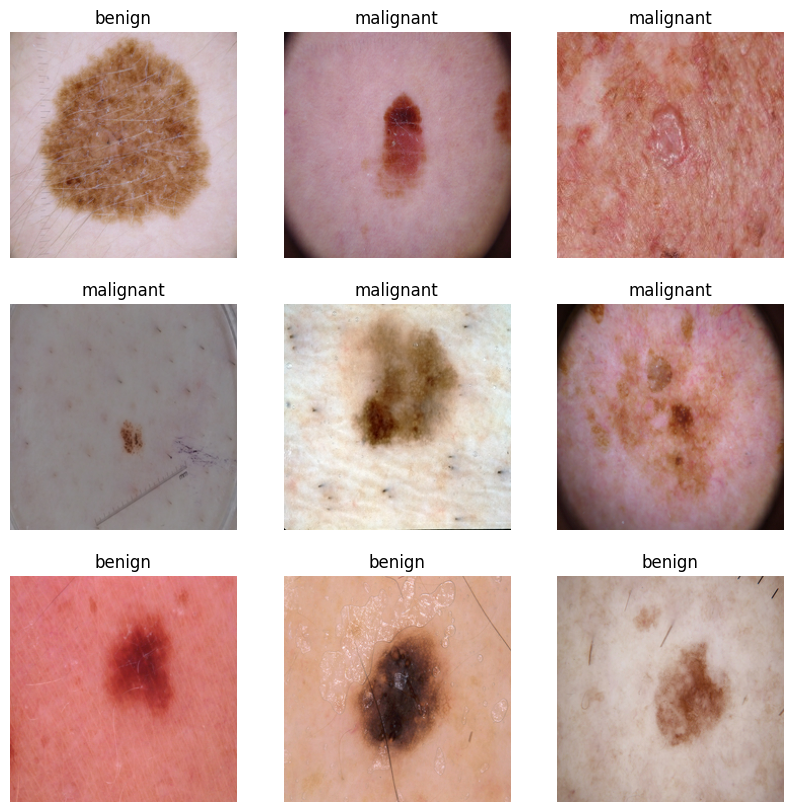

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for images, labels in train_data.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(train_data.class_names[labels[i]])
        plt.axis("off")

In [6]:
import tensorflow as tf
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

In [7]:
import tensorflow as tf
from tensorflow.keras import layers

normalization_layer= layers.Rescaling(1./255)

In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    
    # Normalization
    layers.Rescaling(1./255, input_shape=(224, 224, 3)),
    

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    

    layers.Flatten(),
    
  
    layers.Dense(128, activation='relu'),
    

    layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [9]:
from tensorflow.keras.optimizers import Adam

optimizer = Adam(learning_rate=0.001)

model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [10]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=50
)

Epoch 1/50


I0000 00:00:1777394448.429389      75 service.cc:152] XLA service 0x7c5bb8006f40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777394448.429441      75 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777394448.429448      75 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777394448.848257      75 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-28 16:40:51.240228: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-28 16:40:51.388134: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 4/66 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.5684 - loss: 1.2331

I0000 00:00:1777394453.747975      75 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


65/66 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.6172 - loss: 0.7461

2026-04-28 16:40:59.816736: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-28 16:40:59.964562: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


66/66 ━━━━━━━━━━━━━━━━━━━━ 18s 175ms/step - accuracy: 0.6192 - loss: 0.7412 - val_accuracy: 0.6205 - val_loss: 0.7712
Epoch 2/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.7514 - loss: 0.4689 - val_accuracy: 0.7856 - val_loss: 0.4597
Epoch 3/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.7894 - loss: 0.4119 - val_accuracy: 0.8083 - val_loss: 0.4382
Epoch 4/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.8163 - loss: 0.3704 - val_accuracy: 0.7723 - val_loss: 0.4464
Epoch 5/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.8337 - loss: 0.3618 - val_accuracy: 0.7495 - val_loss: 0.5153
Epoch 6/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.8171 - loss: 0.3344 - val_accuracy: 0.8065 - val_loss: 0.3936
Epoch 7/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.8437 - loss: 0.2954 - val_accuracy: 0.7761 - val_loss: 0.4607
Epoch 8/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.8341 - loss: 0.3111 - val_accuracy: 0.8027 - val_loss: 

In [11]:
test_dir = "/kaggle/input/datasets/hattoriyoung/skin-cancer-data/data/test"
import tensorflow as tf

test_data = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(224, 224),
    batch_size=32
)


test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)

import numpy as np
from sklearn.metrics import classification_report, recall_score, precision_score

y_true, y_pred = [], []

for images, labels in test_data:
    preds = model.predict(images)
    preds = (preds > 0.5).astype(int)

    y_true += list(labels.numpy())
    y_pred += list(preds.flatten())

print("Recall:", recall_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))

print("\nFull Report:\n")
print(classification_report(y_true, y_pred))

Found 660 files belonging to 2 classes.
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 136ms/step - accuracy: 0.8268 - loss: 2.3043
Test Accuracy: 0.8333333134651184
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step
Recall: 0.8333333333333334
Precision: 0.80645161290